In [1]:
import xarray as xr
import rioxarray
import rasterio
from rasterio.enums import Resampling
import glob
import os

# 1. Path to your 26 NetCDF files
nc_folder = r"D:\landslide\tehri_landslide\data\rainfall"
nc_files = glob.glob(os.path.join(nc_folder, "*.nc"))
nc_files.sort()

# 2. Open all years and calculate the Mean Annual Precipitation
# Note: 'chunks' helps if your RAM is low
ds = xr.open_mfdataset(nc_files, combine='by_coords', chunks={'time': 12})
mean_rf = ds['tp'].mean(dim='time') # Verify 'tp' is your variable name

# 3. Standardize the Source (NetCDFs are almost always EPSG:4326)
mean_rf.rio.write_crs("EPSG:4326", inplace=True)

# 4. Reference your 10m UTM Master (EPSG:32644)
master_path = r"D:\landslide\final_data\distance_roads_tehri.tif"
with rasterio.open(master_path) as master:
    dst_crs = master.crs           # This will be EPSG:32644
    dst_transform = master.transform
    dst_width = master.width
    dst_height = master.height

# 5. Reproject and Resample (Degrees -> UTM 44N Meters)
rf_utm_10m = mean_rf.rio.reproject(
    dst_crs,
    shape=(dst_height, dst_width),
    transform=dst_transform,
    resampling=Resampling.bilinear # Smooths out the 25km blocks
)

# 6. Save the final ML-ready file
output_path = r"D:\landslide\final_data\Rainfall_25yr_Mean_UTM_32644.tif"
rf_utm_10m.rio.to_raster(output_path)

print(f"Success! 25-year mean rainfall standardized to UTM 32644 at 10m.")

c:\Users\sangh\anaconda3\envs\football\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


KeyError: "No variable named 'tp'. Variables on the dataset include ['RAINFALL', 'LONGITUDE', 'LATITUDE', 'TIME', 'time', 'lon', 'lat', 'rf']"

In [2]:
import xarray as xr
import rioxarray
import rasterio
from rasterio.enums import Resampling
import glob
import os
import numpy as np

# 1. Paths - Update these to your actual folders
nc_folder = r"D:\landslide\tehri_landslide\data\rainfall"
master_path = r"D:\landslide\final_data\distance_roads_tehri.tif"
output_path = r"D:\landslide\final_data\Rainfall_25yr_Mean_UTM_32644.tif"

# Get all .nc files and sort them
nc_files = glob.glob(os.path.join(nc_folder, "*.nc"))
nc_files.sort()

if not nc_files:
    raise FileNotFoundError(f"No NetCDF files found in {nc_folder}")

print(f"Processing {len(nc_files)} files...")

# 2. Open all years and calculate the Mean
# We use chunks to prevent MemoryErrors
ds = xr.open_mfdataset(nc_files, combine='by_coords', chunks={'time': 12})

# Setting spatial dimensions explicitly to avoid 'No X/Y found' errors
# Based on your error log, 'lon' and 'lat' are available
ds = ds.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)

# Use 'rf' as the variable (identified from your previous error)
target_var = 'rf' 
mean_rf = ds[target_var].mean(dim='time')

# --- UNIT CHECK & CORRECTION ---
# Compute the actual average value to decide on the multiplier
sample_val = float(mean_rf.mean().compute())
print(f"DEBUG: Mean value detected: {sample_val:.4f}")

# If values are < 20, it is likely Daily Rainfall (mm/day)
# We multiply by 365 to get Mean Annual Precipitation (mm/year)
if sample_val < 20:
    print("ACTION: Scaling Daily mm to Annual mm (x365)...")
    mean_rf = mean_rf * 365
else:
    print("ACTION: Values appear to be already in Annual/Accumulated format.")

# 3. Standardize the Source CRS (Standard Geographic WGS84)
mean_rf.rio.write_crs("EPSG:4326", inplace=True)

# 4. Load your 10m UTM Master (EPSG:32644)
with rasterio.open(master_path) as master:
    dst_crs = master.crs           # This will be EPSG:32644
    dst_transform = master.transform
    dst_width = master.width
    dst_height = master.height

# 5. Reproject and Resample (Degrees -> UTM 44N Meters)
print("Reprojecting and Resampling to 10m UTM... Please wait.")
rf_utm_10m = mean_rf.rio.reproject(
    dst_crs,
    shape=(dst_height, dst_width),
    transform=dst_transform,
    resampling=Resampling.bilinear # Essential for smooth climate gradients
)

# 6. Save the final ML-ready file
# Ensure we handle NoData correctly for the final TIF
rf_utm_10m.rio.to_raster(output_path, nodata=-9999.0)

print("-" * 30)
print(f"SUCCESS!")
print(f"Output: {output_path}")
print(f"Final Resolution: 10m x 10m")
print(f"Final CRS: {dst_crs}")

Processing 26 files...


c:\Users\sangh\anaconda3\envs\football\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


DEBUG: Mean value detected: 3.3437
ACTION: Scaling Daily mm to Annual mm (x365)...
Reprojecting and Resampling to 10m UTM... Please wait.
------------------------------
SUCCESS!
Output: D:\landslide\final_data\Rainfall_25yr_Mean_UTM_32644.tif
Final Resolution: 10m x 10m
Final CRS: EPSG:32644


--- TEST 1: SPATIAL ALIGNMENT ---
CRS Matches (EPSG:32644): True
Pixel Dimensions Match: True (10741x9084)
Bounding Box Matches: True
✅ PASSED: Spatial alignment is perfect.

--- TEST 2: STATISTICAL VALIDITY ---
Min Annual Rainfall: 669.06 mm
Max Annual Rainfall: 2103.35 mm
Mean Annual Rainfall: 1460.99 mm
✅ PASSED: Rainfall values are within realistic Himalayan ranges.

--- TEST 3: VISUALIZING DISTRIBUTION ---


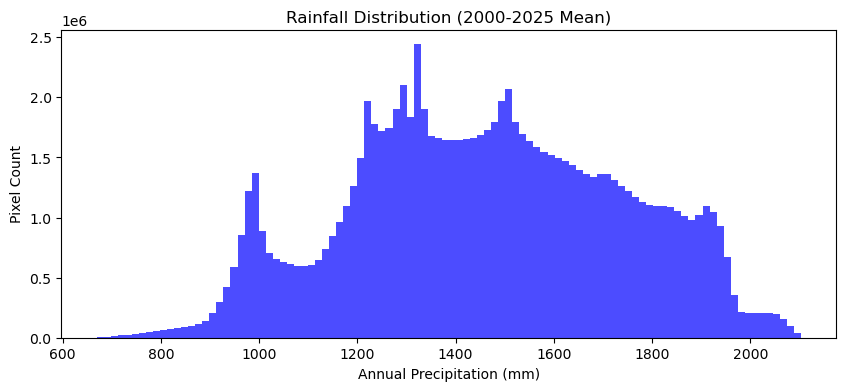

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Paths
rf_path = r"D:\landslide\final_data\Rainfall_25yr_Mean_UTM_32644.tif"
master_path = r"D:\landslide\final_data\distance_roads_tehri.tif"

def verify_rainfall():
    with rasterio.open(rf_path) as rf, rasterio.open(master_path) as master:
        # 1. SPATIAL ALIGNMENT TEST
        print("--- TEST 1: SPATIAL ALIGNMENT ---")
        crs_match = rf.crs == master.crs
        shape_match = rf.shape == master.shape
        bounds_match = np.allclose(rf.bounds, master.bounds, atol=1e-3)
        
        print(f"CRS Matches (EPSG:32644): {crs_match}")
        print(f"Pixel Dimensions Match: {shape_match} ({rf.width}x{rf.height})")
        print(f"Bounding Box Matches: {bounds_match}")
        
        if not (crs_match and shape_match):
            print("❌ FAILED: Rainfall will not align with other features in the CSV.")
        else:
            print("✅ PASSED: Spatial alignment is perfect.")

        # 2. STATISTICAL RANGE TEST
        print("\n--- TEST 2: STATISTICAL VALIDITY ---")
        data = rf.read(1)
        valid_data = data[data != rf.nodata]
        
        rf_min, rf_max = np.min(valid_data), np.max(valid_data)
        rf_mean = np.mean(valid_data)
        
        print(f"Min Annual Rainfall: {rf_min:.2f} mm")
        print(f"Max Annual Rainfall: {rf_max:.2f} mm")
        print(f"Mean Annual Rainfall: {rf_mean:.2f} mm")
        
        # Tehri Garhwal Logic Check
        if rf_mean < 500:
            print("⚠️ WARNING: Rainfall looks too low for the Himalayas. Check multipliers.")
        elif rf_mean > 5000:
            print("⚠️ WARNING: Rainfall looks impossibly high. Check units.")
        else:
            print("✅ PASSED: Rainfall values are within realistic Himalayan ranges.")

        # 3. VISUAL DISTRIBUTION TEST
        print("\n--- TEST 3: VISUALIZING DISTRIBUTION ---")
        plt.figure(figsize=(10, 4))
        plt.hist(valid_data, bins=100, color='blue', alpha=0.7)
        plt.title("Rainfall Distribution (2000-2025 Mean)")
        plt.xlabel("Annual Precipitation (mm)")
        plt.ylabel("Pixel Count")
        plt.show()

verify_rainfall()

In [4]:
import rasterio

# Paths to your files
rf_path = r"D:\landslide\final_data\Rainfall_25yr_Mean_UTM_32644.tif"
master_path = r"D:\landslide\final_data\distance_roads_tehri.tif"

def check_resolution_and_alignment():
    with rasterio.open(rf_path) as rf, rasterio.open(master_path) as master:
        # 1. Get exact pixel resolution (Width, Height in meters)
        rf_res = rf.res
        master_res = master.res
        
        # 2. Get the corner coordinates (Top-Left)
        rf_tl = (rf.transform[2], rf.transform[5])
        master_tl = (master.transform[2], master.transform[5])
        
        print(f"--- RESOLUTION CHECK ---")
        print(f"Rainfall Resolution: {rf_res[0]}m x {rf_res[1]}m")
        print(f"Master Resolution:   {master_res[0]}m x {master_res[1]}m")
        
        print(f"\n--- ALIGNMENT CHECK (Top-Left Corner) ---")
        print(f"Rainfall Origin: {rf_tl}")
        print(f"Master Origin:   {master_tl}")
        
        # Validation Logic
        if rf_res == master_res and rf_tl == master_tl:
            print("\n✅ PERFECT MATCH: Rasters are exactly 10m and perfectly aligned.")
        else:
            print("\n❌ MISMATCH DETECTED: Your CSV extraction will be shifted!")
            if rf_res != master_res:
                print(f"   -> Resolution difference: {abs(rf_res[0]-master_res[0])}m")
            if rf_tl != master_tl:
                print(f"   -> Spatial offset: {abs(rf_tl[0]-master_tl[0])} meters")

check_resolution_and_alignment()

--- RESOLUTION CHECK ---
Rainfall Resolution: 10.0m x 10.0m
Master Resolution:   10.0m x 10.0m

--- ALIGNMENT CHECK (Top-Left Corner) ---
Rainfall Origin: (205020.22167920484, 3418646.3940297123)
Master Origin:   (205020.22167920484, 3418646.3940297123)

✅ PERFECT MATCH: Rasters are exactly 10m and perfectly aligned.


In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LightSource

# Paths
rf_path = r"D:\landslide\final_data\Rainfall_25yr_Mean_UTM_32644.tif"
elev_path = r"D:\landslide\final_data\Elevation_10m.tif"

with rasterio.open(rf_path) as rf_src, rasterio.open(elev_path) as elev_src:
    rf_data = rf_src.read(1)
    elev_data = elev_src.read(1)
    
    # Mask NoData values for better visualization
    rf_data = np.where(rf_data == rf_src.nodata, np.nan, rf_data)
    elev_data = np.where(elev_data == elev_src.nodata, np.nan, elev_data)

    # Create a Hillshade from Elevation to provide terrain context
    ls = LightSource(azdeg=315, altdeg=45)
    hillshade = ls.hillshade(elev_data, vert_exag=1)

    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Show Hillshade as background
    ax.imshow(hillshade, cmap='gray', alpha=0.3)
    
    # Overlay Rainfall with transparency
    img = ax.imshow(rf_data, cmap='YlGnBu', alpha=0.7)
    
    plt.colorbar(img, label='Mean Annual Rainfall (mm)')
    ax.set_title("25-Year Mean Annual Rainfall (2000-2025) \n Overlaid on Tehri Terrain (10m UTM)")
    ax.axis('off')
    
    plt.show()

    # Summary Statistics printout
    print(f"Rainfall Min: {np.nanmin(rf_data):.2f} mm")
    print(f"Rainfall Max: {np.nanmax(rf_data):.2f} mm")
    print(f"Rainfall Mean: {np.nanmean(rf_data):.2f} mm")

MemoryError: Unable to allocate 2.91 GiB for an array with shape (9084, 10741, 4) and data type float64

<Figure size 1200x1000 with 2 Axes>

Rainfall Min: 669.06 mm
Rainfall Max: 2103.35 mm
